# Pipeline Tag Prediction

## Model B: Modern BERT
**DATASCI 266: Natural Language Processing with Deep Learning**

UC Berkeley, School of Information

---

This notebook implements an improvement model over the baseline using modernBERT-base with truncation to 512 tokens. It runs in this order:

1. Load split dataframes used in baseline
2. Setup tokenizer
3. Setup HuggingFace Datasets
4. Data collator
5. ModernBERT model
6. Setup training configuration and train model
7. Predictions and metric analysis


## 0. Setup

In [1]:
!pip install -q -U transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 15.6 MB/s eta 0:00:00


In [2]:
import os, gc, warnings, json
import numpy as np
import pandas as pd
import torch
import evaluate
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
    set_seed,
)

warnings.filterwarnings("ignore")

SEED = 42
set_seed(SEED)

# Plot defaults
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 5)})

device = torch.device("cuda")
print("GPU:", torch.cuda.get_device_name(0))
print("VRAM: {:.1f} GB".format(torch.cuda.get_device_properties(0).total_memory / 1e9))
print("Libraries loaded ✓")

GPU: Tesla T4
VRAM: 15.6 GB
Libraries loaded ✓


## 1. Load DataFrames

Import the train, test, and validation dataframes that were used for the baseline. They underwent an 80/20/20 split. This ensures we are using the same exact dataset across all models to best inform our model and error analysis.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE_DIR_2 = '/content/drive/MyDrive/266-pipeline-tag-prediction'

train_df = pd.read_parquet(f'{DRIVE_DIR_2}/train_df.parquet')
val_df = pd.read_parquet(f'{DRIVE_DIR_2}/val_df.parquet')
test_df = pd.read_parquet(f'{DRIVE_DIR_2}/test_df.parquet')

metadata = json.load(open(f'{DRIVE_DIR_2}/metadata.json'))
label2id, id2label = metadata['label2id'], metadata['id2label']

Mounted at /content/drive


In [4]:
# Verify shapes for each df
print("Shape of train:", train_df.shape)
print("Shape of validation:", val_df.shape)
print("Shape of test:", test_df.shape)

Shape of train: (112828, 7)
Shape of validation: (14104, 7)
Shape of test: (14104, 7)


## 2. Tokenizer

ModernBERT-base supports up to an 8,192-token context. We limit the context window based on the actual distribution of model-card text lengths rather than defaulting to the full context window to preserve memory so the T4 GPU does not fail to support the model training.

In [5]:
# Load tokenizer from ModernBERT-base
modernBERT_checkpoint = "answerdotai/ModernBERT-base"
modernBERT_tokenizer = AutoTokenizer.from_pretrained(modernBERT_checkpoint)

config.json:   0%|          | 0.00/1.19k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.13M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

In [6]:
# Random sample check in training dataset to set context window limit
sample_texts = train_df['text'].sample(n=min(3000, len(train_df)), random_state=SEED).tolist()
sample_lengths = [len(ids) for ids in modernBERT_tokenizer(sample_texts, truncation=False)['input_ids']]

percentiles = np.percentile(sample_lengths, [50, 75, 90, 95, 99])
print("Token length percentiles (sample of {}):".format(len(sample_lengths)))
for p, v in zip([50, 75, 90, 95, 99], percentiles):
    print(f"  p{p}: {v:.0f} tokens")
print(f"  max: {max(sample_lengths)} tokens")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (13036 > 8192). Running this sequence through the model will result in indexing errors


Token length percentiles (sample of 3000):
  p50: 680 tokens
  p75: 1507 tokens
  p90: 3139 tokens
  p95: 4937 tokens
  p99: 10823 tokens
  max: 36917 tokens


In [7]:
def tokenize_batch(batch):
    tokenized = modernBERT_tokenizer(
        batch["text"],
        truncation=True,
        max_length=512,
    )
    tokenized["length"] = [len(ids) for ids in tokenized["input_ids"]]
    return tokenized

tokenize_kwargs = dict(
    batched=True,
    batch_size=1000,
    num_proc=max(1, os.cpu_count() - 1),
    remove_columns=["text"],
)

## 3. Convert DataFrames into pre-tokenized Hugging Face Dataset objects

Setup the data to be usable by the tokenizer, model, and trainer.

In [8]:
# Convert DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df[["text", "label"]], preserve_index=False)
val_dataset = Dataset.from_pandas(val_df[["text", "label"]], preserve_index=False)
test_dataset = Dataset.from_pandas(test_df[["text", "label"]], preserve_index=False)

In [9]:
train_dataset = train_dataset.map(tokenize_batch, **tokenize_kwargs)
val_dataset = val_dataset.map(tokenize_batch, **tokenize_kwargs)
test_dataset = test_dataset.map(tokenize_batch, **tokenize_kwargs)

train_dataset = train_dataset.rename_column("label", "labels")
val_dataset = val_dataset.rename_column("label", "labels")
test_dataset = test_dataset.rename_column("label", "labels")

print(train_dataset)

Map (num_proc=1):   0%|          | 0/112828 [00:00<?, ? examples/s]

Map (num_proc=1):   0%|          | 0/14104 [00:00<?, ? examples/s]

Map (num_proc=1):   0%|          | 0/14104 [00:00<?, ? examples/s]

Dataset({
    features: ['labels', 'input_ids', 'attention_mask', 'length'],
    num_rows: 112828
})


## 4. Data Collator

Setup dynamic padding to the longest sequence per batch to maximize compatibility with the current T4 GPU environment.

In [10]:
data_collator = DataCollatorWithPadding(
    tokenizer=modernBERT_tokenizer,
    padding="longest",
    pad_to_multiple_of=8,
)

## 5. ModernBERT Model

In [11]:
# Load model

num_labels = len(label2id)
modernBERT_model = AutoModelForSequenceClassification.from_pretrained(
    modernBERT_checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    attn_implementation="sdpa",
)

# Setup metrics - accuracy and F1
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro")
    }

model.safetensors: reconstructing file:   0%|          |  0.00B /  599MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

[transformers] ModernBertForSequenceClassification LOAD REPORT from: answerdotai/ModernBERT-base
Key               | Status     | 
------------------+------------+-
decoder.bias      | UNEXPECTED | 
classifier.bias   | MISSING    | 
classifier.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 6. Train

Setup training argument parameters and the trainer.


- `fp16=True` — T4 (Turing) supports fp16 tensor cores but **not** bf16/tf32, so fp16 is the correct mixed-precision choice here.
- `gradient_checkpointing=False` by default — with `MAX_LENGTH=512` and `BATCH_SIZE=16`, ModernBERT-base comfortably fits in 16GB without it, and checkpointing meaningfully slows training. It's turned on automatically only if an OOM is actually hit (see the guarded training cell below).
- `group_by_length=True` — batches similarly-long sequences together to minimize padding waste, which matters a lot with variable-length model-card text.
- `save_total_limit=2` — keeps Colab's disk from filling up over multiple epochs of checkpoints.
- `load_best_model_at_end=True` + `EarlyStoppingCallback` — stops wasted epochs once validation macro-F1 stops improving.

In [13]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    learning_rate=2e-5,
    num_train_epochs=1,
    # tuning for T4 speed
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,
    fp16=True,
    bf16=False,
    gradient_checkpointing=False,
    length_column_name="length",
    optim="adamw_torch_fused",
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    dataloader_persistent_workers=True,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    seed=SEED,
    report_to="none"
)


trainer = Trainer(
    model=modernBERT_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)


Uncomment the block below to check GPU usage while training is running.

In [ ]:
# import subprocess, threading, time

# def log_gpu(interval=5, duration=60):
#     end = time.time() + duration
#     while time.time() < end:
#         out = subprocess.run(
#             ["nvidia-smi", "--query-gpu=utilization.gpu,memory.used", "--format=csv,noheader"],
#             capture_output=True, text=True
#         )
#         print(out.stdout.strip())
#         time.sleep(interval)

# threading.Thread(target=log_gpu, args=(5, 60)).start()

In [14]:
def train_with_oom_guard(trainer, max_retries=2):
    """Runs trainer.train(); if a CUDA OOM is hit, halves the batch size, doubles
    gradient accumulation (preserving the effective batch size), enables gradient
    checkpointing, clears the cache, and retries — instead of crashing the run."""
    for attempt in range(max_retries + 1):
        try:
            return trainer.train()
        except torch.cuda.OutOfMemoryError as e:
            if attempt == max_retries:
                raise
            print(f"\n[OOM guard] CUDA OOM on attempt {attempt + 1}: {e}")
            print("[OOM guard] Reducing batch size, enabling gradient checkpointing, and retrying...\n")

            del trainer
            gc.collect()
            torch.cuda.empty_cache()

            training_args.per_device_train_batch_size = max(1, training_args.per_device_train_batch_size // 2)
            training_args.per_device_eval_batch_size = max(1, training_args.per_device_eval_batch_size // 2)
            training_args.gradient_accumulation_steps *= 2
            training_args.gradient_checkpointing = True

            modernBERT_model.gradient_checkpointing_enable()
            modernBERT_model.config.use_cache = False

            trainer = Trainer(
                model=modernBERT_model,
                args=training_args,
                train_dataset=train_dataset,
                eval_dataset=val_dataset,
                compute_metrics=compute_metrics,
                data_collator=data_collator,
                callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
            )
            print(f"[OOM guard] Retrying with per_device_train_batch_size="
                  f"{training_args.per_device_train_batch_size}, "
                  f"gradient_accumulation_steps={training_args.gradient_accumulation_steps}")

In [15]:
# Run train
train_with_oom_guard(trainer)

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.256967,0.119065,0.963769,0.960705


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3526, training_loss=0.40885578903094383, metrics={'train_runtime': 5187.6137, 'train_samples_per_second': 21.749, 'train_steps_per_second': 0.68, 'total_flos': 3.844915858034688e+16, 'train_loss': 0.40885578903094383, 'epoch': 1.0})

In [16]:
# Evaluate training
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.256967,0.119065,1,0.963769,0.960705


{'eval_loss': 0.11906468868255615,
 'eval_accuracy': 0.9637691435053886,
 'eval_macro_f1': 0.9607048685195588}

## 7. Predictions and Metric Analysis

In [18]:
test_predictions = trainer.predict(test_dataset)
preds = np.argmax(test_predictions.predictions, axis=-1)
true_labels = test_predictions.label_ids

print("Test metrics:", test_predictions.metrics)

Test metrics: {'test_loss': 0.12930506467819214, 'test_accuracy': 0.9630601247872944, 'test_macro_f1': 0.9587801509296081, 'test_runtime': 208.1023, 'test_samples_per_second': 67.774, 'test_steps_per_second': 2.119}


In [19]:
# Classification Report

target_names = [id2label[str(i)] for i in range(len(id2label))]

print(classification_report(
    true_labels,
    preds,
    target_names=target_names
))

                              precision    recall  f1-score   support

automatic-speech-recognition       0.99      0.97      0.98       617
        image-classification       0.96      0.97      0.97       331
          image-text-to-text       0.91      0.85      0.88      1240
                    robotics       0.96      0.97      0.96       347
         sentence-similarity       0.98      0.98      0.98       343
         text-classification       0.96      0.93      0.94      1033
             text-generation       0.96      0.98      0.97      6689
               text-to-image       0.99      0.99      0.99      2239
        token-classification       0.95      0.93      0.94       362
                 translation       0.99      0.96      0.97       903

                    accuracy                           0.96     14104
                   macro avg       0.96      0.95      0.96     14104
                weighted avg       0.96      0.96      0.96     14104



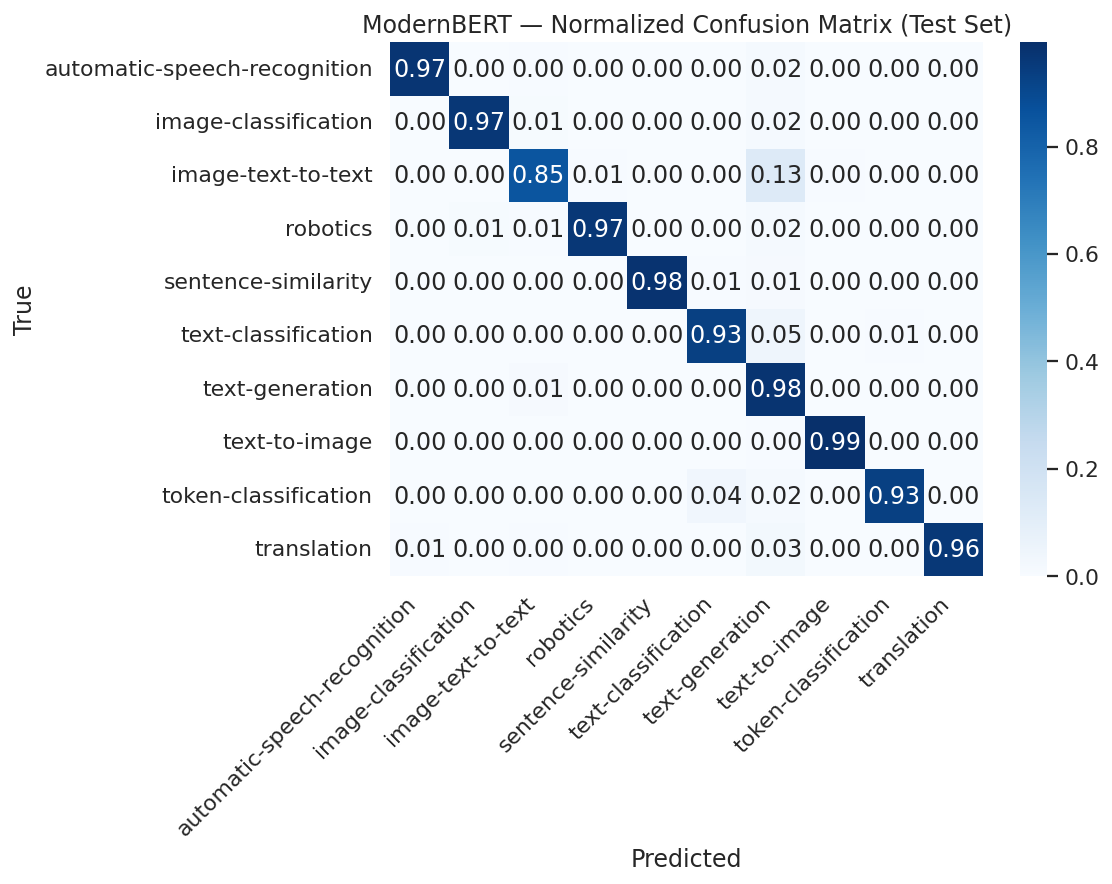

In [20]:
# Confusion matrix
cm = confusion_matrix(true_labels, preds, normalize="true")

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("ModernBERT — Normalized Confusion Matrix (Test Set)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [21]:
# Save the fine-tuned model and tokenizer back to Google Drive to reuse it
save_dir = f'{DRIVE_DIR_2}/modernbert_pipeline_tag_model'
trainer.save_model(save_dir)
modernBERT_tokenizer.save_pretrained(save_dir)
print(f"Model saved to {save_dir}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to /content/drive/MyDrive/266-pipeline-tag-prediction/modernbert_pipeline_tag_model
